In [ ]:
!pip install sqlalchemy pymysql python-dotenv pandas seaborn matplotlib scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.3 MB/s eta 0:00:00


In [ ]:
DB_HOST= "shtm-fallprev.mysql.database.azure.com"
DB_USER= "ahistudent"
DB_PASSWORD= "researcher"
DB_NAME= "sbu_athletics"
DB_TABLE= "research_experiment_refactor_test"

print("Credentials loaded.")

Credentials loaded.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from scipy import stats

%matplotlib inline

# Create connection engine
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

# Test query
test_df = pd.read_sql(f"SELECT * FROM {DB_TABLE} LIMIT 5", engine)
test_df


,id,playername,timestamp,device,metric,value,team,session_type,session_description,function_description,data_source,created_at
0,1,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Force(N),1546.3816,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
1,2,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Power(W),-1099.2175,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
2,3,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Velocity(m/s),-0.7630,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
3,4,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Landing Force(N),1251.3600,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
4,5,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Propulsive Force(N),1887.0421,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54


In [ ]:
METRICS = [
    "Jump Height(m)",
    "Peak Propulsive Force(N)",
    "RSI"
]


In [ ]:
METRIC_NAME = METRICS[0]
query_teams = f"""
SELECT team, COUNT(*) AS num_rows
FROM {DB_TABLE}
WHERE metric = '{METRIC_NAME}' AND team IS NOT NULL
GROUP BY team
ORDER BY num_rows DESC
LIMIT 10;
"""

teams_df = pd.read_sql(query_teams, engine)
teams_df

,team,num_rows
0,"Group: WLAX , Group: WLAX Spring '24, Team: SB...",2885
1,Team: Stony Brook Womens Soccer,2335
2,"Group: 2023-2024 WBB, Group: Women's Basketbal...",2037
3,Team: Stony Brook Swimming and Diving,2021
4,Team: Stony Brook MLAX,1536
5,Team: Stony Brook Women's Volleyball,1523
6,Team: Stony Brook Softball,1505
7,Team: Stony Brook Men's Soccer,1247
8,"Group: Football Big Skill, Team: Stony Brook F...",1185
9,"Group: Football Skill, Team: Stony Brook Football",1133


In [ ]:
TEAM_A = "Team: Stony Brook Womens Soccer"
TEAM_B = "Team: Stony Brook Women's Volleyball"

TEAM_A, TEAM_B


('Team: Stony Brook Womens Soccer', "Team: Stony Brook Women's Volleyball")

In [ ]:
METRICS = [
    "Jump Height(m)",
    "Peak Propulsive Force(N)",
    "RSI"
]

query_data = f"""
SELECT playername, team, timestamp, metric, value
FROM {DB_TABLE}
WHERE metric IN (
    'Jump Height(m)',
    'Peak Propulsive Force(N)',
    'RSI'
)
  AND team IN (%s, %s)
  AND value IS NOT NULL
"""

df = pd.read_sql(query_data, engine, params=(TEAM_A, TEAM_B))

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df.head(), len(df)


(   playername                                  team           timestamp  \
 0  PLAYER_914  Team: Stony Brook Women's Volleyball 2019-04-23 13:07:49   
 1  PLAYER_396  Team: Stony Brook Women's Volleyball 2019-04-23 13:08:06   
 2  PLAYER_460  Team: Stony Brook Women's Volleyball 2019-04-23 13:08:21   
 3  PLAYER_748  Team: Stony Brook Women's Volleyball 2019-04-23 13:08:53   
 4  PLAYER_771  Team: Stony Brook Women's Volleyball 2019-04-23 13:09:09   
 
            metric   value  
 0  Jump Height(m)  0.3402  
 1  Jump Height(m)  0.4065  
 2  Jump Height(m)  0.4658  
 3  Jump Height(m)  0.3557  
 4  Jump Height(m)  0.2852  ,
 11574)


Metric: Jump Height(m)
Rows for this metric: 3858


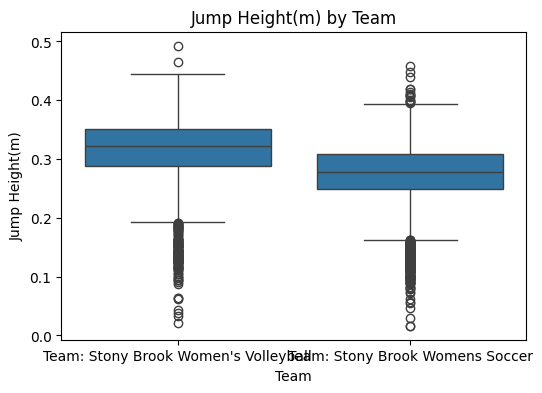

Samples for Team: Stony Brook Womens Soccer: 2335
Samples for Team: Stony Brook Women's Volleyball: 1523
t-statistic: -16.86810328770749
p-value   : 4.428037252207331e-61

Metric: Peak Propulsive Force(N)
Rows for this metric: 3858


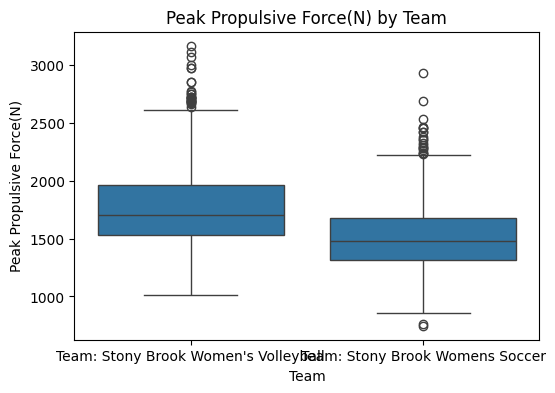

Samples for Team: Stony Brook Womens Soccer: 2335
Samples for Team: Stony Brook Women's Volleyball: 1523
t-statistic: -25.172532099439263
p-value   : 6.66915026847641e-126

Metric: RSI
Rows for this metric: 3858


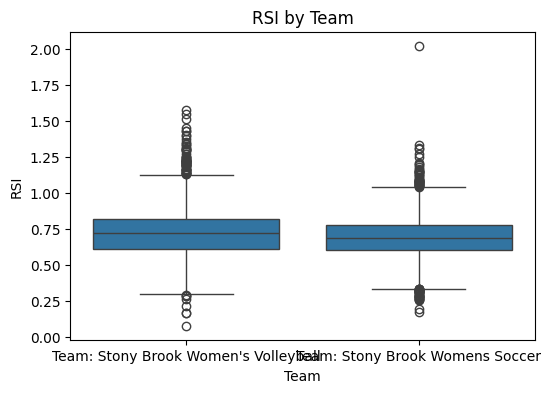

Samples for Team: Stony Brook Womens Soccer: 2335
Samples for Team: Stony Brook Women's Volleyball: 1523
t-statistic: -6.5828315913200415
p-value   : 5.4771312652622384e-11


In [ ]:
for metric in METRICS:
    print("\n==============================")
    print("Metric:", metric)

    # Filter to just this metric
    sub = df[df["metric"] == metric].copy()
    print("Rows for this metric:", len(sub))

    if sub.empty:
        print("No data for this metric for these teams. Skipping.")
        continue

    # ----- Box plot -----
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=sub, x="team", y="value")
    plt.title(f"{metric} by Team")
    plt.xlabel("Team")
    plt.ylabel(metric)
    plt.show()

    # ----- T-test -----
    values_a = sub[sub["team"] == TEAM_A]["value"].dropna()
    values_b = sub[sub["team"] == TEAM_B]["value"].dropna()

    print(f"Samples for {TEAM_A}: {len(values_a)}")
    print(f"Samples for {TEAM_B}: {len(values_b)}")

    if len(values_a) > 1 and len(values_b) > 1:
        t_stat, p_value = stats.ttest_ind(values_a, values_b, equal_var=False)
        print("t-statistic:", t_stat)
        print("p-value   :", p_value)
    else:
        print("Not enough data for t-test.")


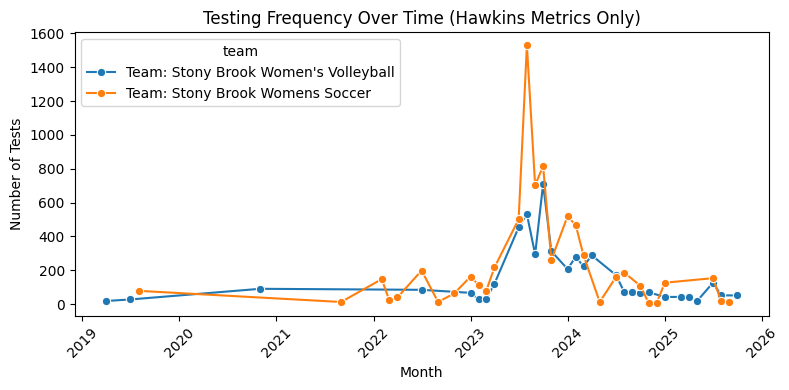

In [ ]:
df["month"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()

freq = (
    df.groupby(["team", "month"])
      .size()
      .reset_index(name="num_tests")
)

freq.head()

plt.figure(figsize=(8, 4))
sns.lineplot(data=freq, x="month", y="num_tests", hue="team", marker="o")
plt.title("Testing Frequency Over Time (Hawkins Metrics Only)")
plt.xlabel("Month")
plt.ylabel("Number of Tests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## **Analysis Overview**

Three Hawkins performance metrics were analyzed for **Team: Stony Brook Womens Soccer** and **Team: Stony Brook Women’s Volleyball**:

* **Jump Height (m)**
* **Peak Propulsive Force (N)**
* **RSI (Reactive Strength Index)**

These metrics represent lower-body performance and are commonly used in athlete monitoring.

---

## **Metric Comparisons Between Teams**

### **Jump Height (m)**

A total of **3858 observations** were available for this metric (Soccer: **2335**, Volleyball: **1523**).
The box plot showed different distributions between the two teams.
The t-test result showed a statistically significant difference (**p = 4.43e-61**), indicating that the teams performed differently in jump height.

### **Peak Propulsive Force (N)**

This metric also contained **3858 observations** (Soccer: **2335**, Volleyball: **1523**).
The t-test produced a very small p-value (**6.67e-126**), showing a highly significant difference between the two teams.
This suggests clear variation between the groups in force generation during the propulsive phase of the jump.

### **RSI (Reactive Strength Index)**

RSI had the same number of observations (Soccer: **2335**, Volleyball: **1523**).
The t-test again showed a statistically significant difference (**p = 5.48e-11**).
This indicates meaningful differences between the teams in their stretch-shortening performance.

### **Interpretation of Metric Results**

All three Hawkins metrics showed statistically significant differences between the two teams.
These differences likely reflect variations in sport demands, training emphasis, and movement characteristics between soccer and volleyball athletes.

---

## **Testing Frequency Over Time**

A monthly testing-frequency plot was generated using all three Hawkins metrics.
The plot shows:

* **Low and steady testing** from 2019 through 2021
* **A clear rise in testing activity** beginning in 2022
* **A large spike during 2023–2024**, especially for Women’s Soccer
* **More variable testing patterns** after the peak, with both teams showing alternating periods of higher and lower testing
* **A gradual decline** moving into 2025

This pattern suggests increased monitoring and data collection during certain training periods or competitive seasons, followed by reduced testing afterward.

---


Clear differences were observed between the two teams across all three Hawkins metrics. The testing frequency plot showed distinct periods of high and low testing activity, indicating changes in monitoring intensity over time. Together, these results provide insight into how each team’s physical performance characteristics and testing schedules vary across the dataset.



In [ ]:
## 3.3 Dashboard Metric – Monthly Test Volume (All Data Sources)


In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Re-including credential definitions directly in this cell
DB_HOST= "shtm-fallprev.mysql.database.azure.com"
DB_USER= "ahistudent"
DB_PASSWORD= "researcher"
DB_NAME= "sbu_athletics"
DB_TABLE= "research_experiment_refactor_test"

# Create connection engine using already defined variables
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

query_all = f"SELECT * FROM {DB_TABLE}"
df = pd.read_sql(query_all, engine)

df.head()

,id,playername,timestamp,device,metric,value,team,session_type,session_description,function_description,data_source,created_at
0,1,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Force(N),1546.3816,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
1,2,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Power(W),-1099.2175,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
2,3,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Velocity(m/s),-0.7630,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
3,4,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Landing Force(N),1251.3600,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
4,5,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Propulsive Force(N),1887.0421,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.7 MB/s eta 0:00:00
Full table loaded. Shape: (6617426, 12)


,id,playername,timestamp,device,metric,value,team,session_type,session_description,function_description,data_source,created_at
0,1,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Force(N),1546.3816,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
1,2,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Power(W),-1099.2175,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
2,3,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Velocity(m/s),-0.7630,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
3,4,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Landing Force(N),1251.3600,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
4,5,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Propulsive Force(N),1887.0421,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54



Monthly counts (first few rows):


,month,data_source,num_tests
0,2018-10,hawkins,1545
1,2019-01,hawkins,304
2,2019-04,hawkins,587
3,2019-05,hawkins,61
4,2019-06,hawkins,398



Pivot table used for plotting:


data_source,hawkins,kinexon,vald
month,,,
2018-10,1545.0,0.0,0.0
2019-01,304.0,0.0,0.0
2019-04,587.0,0.0,0.0
2019-05,61.0,0.0,0.0
2019-06,398.0,0.0,0.0


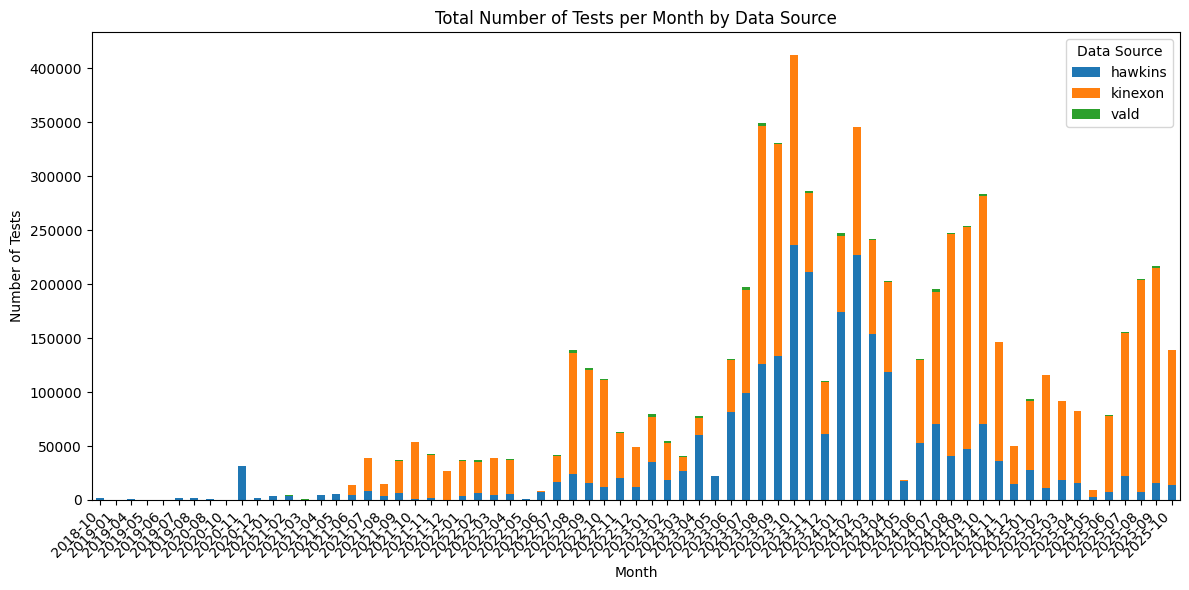


Total tests per month (all data sources combined):


,0
month,
2018-10,1545.0
2019-01,304.0
2019-04,587.0
2019-05,61.0
2019-06,398.0
...,...
2025-06,78824.0
2025-07,155523.0
2025-08,204986.0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

!pip install pymysql

# 1. Reuse or recreate connection and load the FULL table
# DB_HOST, DB_USER, DB_PASSWORD, DB_NAME, and DB_TABLE are already defined globally.

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

query_all = f"SELECT * FROM {DB_TABLE}"
df = pd.read_sql(query_all, engine)

print("Full table loaded. Shape:", df.shape)
display(df.head())

# 2. Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# 3. Create a month column in YYYY-MM format
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

# 4. Group by month and data_source to count number of tests
monthly_counts = (
    df.groupby(["month", "data_source"])
      .size()
      .reset_index(name="num_tests")
)

print("\nMonthly counts (first few rows):")
display(monthly_counts.head())

# 5. Pivot for stacked bar chart: rows = month, columns = data_source
pivot_counts = (
    monthly_counts
    .pivot(index="month", columns="data_source", values="num_tests")
    .fillna(0)
)

# Sort months in chronological order
pivot_counts = pivot_counts.sort_index()

print("\nPivot table used for plotting:")
display(pivot_counts.head())

# 6. Plot stacked bar chart
plt.figure(figsize=(12, 6))
pivot_counts.plot(kind="bar", stacked=True, ax=plt.gca())

plt.title("Total Number of Tests per Month by Data Source")
plt.xlabel("Month")
plt.ylabel("Number of Tests")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Data Source")
plt.tight_layout()
plt.show()

# 7. (Optional) Quick summary of total tests per month
total_per_month = pivot_counts.sum(axis=1)
print("\nTotal tests per month (all data sources combined):")
display(total_per_month)

In [ ]:
# 3.3 – Prepare monthly test counts by data_source

# 1. Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# 2. Create a month column in YYYY-MM format
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

# 3. Group by month and data_source to count number of tests
monthly_counts = (
    df.groupby(["month", "data_source"])
      .size()
      .reset_index(name="num_tests")
)

print("Monthly counts (first few rows):")
display(monthly_counts.head())

# 4. Pivot for stacked bar chart (rows = month, columns = data_source)
pivot_counts = (
    monthly_counts
      .pivot(index="month", columns="data_source", values="num_tests")
      .fillna(0)
      .sort_index()
)

print("\nPivot table used for plotting:")
display(pivot_counts.head())


Monthly counts (first few rows):


,month,data_source,num_tests
0,2018-10,hawkins,1545
1,2019-01,hawkins,304
2,2019-04,hawkins,587
3,2019-05,hawkins,61
4,2019-06,hawkins,398



Pivot table used for plotting:


data_source,hawkins,kinexon,vald
month,,,
2018-10,1545.0,0.0,0.0
2019-01,304.0,0.0,0.0
2019-04,587.0,0.0,0.0
2019-05,61.0,0.0,0.0
2019-06,398.0,0.0,0.0


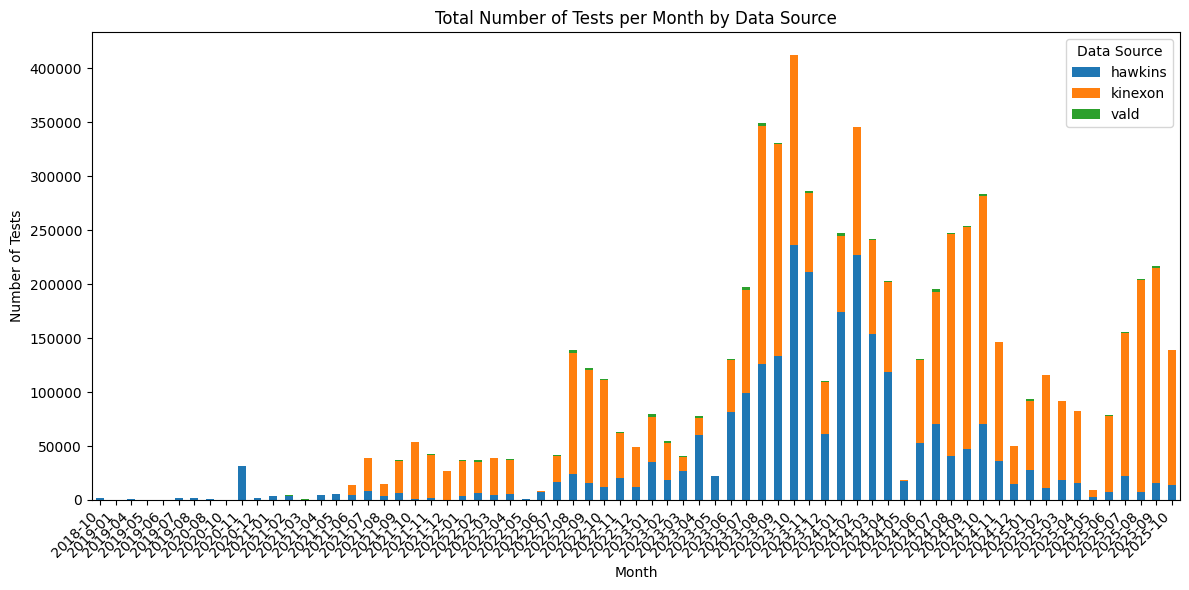

In [ ]:
# 3.3 – Stacked bar chart: total tests per month by data_source

plt.figure(figsize=(12, 6))

pivot_counts.plot(kind="bar", stacked=True, ax=plt.gca())

plt.title("Total Number of Tests per Month by Data Source")
plt.xlabel("Month")
plt.ylabel("Number of Tests")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Data Source")
plt.tight_layout()
plt.show()


In [ ]:
# 3.3 – Total tests per month (all data sources combined)

total_per_month = pivot_counts.sum(axis=1)
print("Total tests per month (all sources):")
display(total_per_month)


Total tests per month (all sources):


,0
month,
2018-10,1545.0
2019-01,304.0
2019-04,587.0
2019-05,61.0
2019-06,398.0
...,...
2025-06,78824.0
2025-07,155523.0
2025-08,204986.0


In [11]:
interpretation = """
### 3.3 Dashboard Metric Interpretation

The stacked bar chart shows monthly testing volume across all data sources.
Testing activity is highest around **2023–2024**, especially in months such as **2023-08, 2023-11, and early 2024**, with most tests coming from **Kinexon**, followed by Hawkins.
There are noticeable drops in testing during **2019–2021** and again in **late 2024–2025**, which may reflect off-season periods, reduced monitoring, or gaps in data collection.
Some data sources (for example, **Kinexon**) appear far more consistently used than others, while **Vald** is used minimally and contributes very few tests overall.
Overall, this dashboard highlights a major increase in monitoring during 2023–2024, strong reliance on Kinexon data, and clear periods where athlete testing was reduced.
"""
print(interpretation)



### 3.3 Dashboard Metric Interpretation

The stacked bar chart shows monthly testing volume across all data sources.
Testing activity is highest around **2023–2024**, especially in months such as **2023-08, 2023-11, and early 2024**, with most tests coming from **Kinexon**, followed by Hawkins.  
There are noticeable drops in testing during **2019–2021** and again in **late 2024–2025**, which may reflect off-season periods, reduced monitoring, or gaps in data collection.  
Some data sources (for example, **Kinexon**) appear far more consistently used than others, while **Vald** is used minimally and contributes very few tests overall.  
Overall, this dashboard highlights a major increase in monitoring during 2023–2024, strong reliance on Kinexon data, and clear periods where athlete testing was reduced.

